# ISTVT — Interpretability Visualization
*(Paper Sec. III-D, Algorithm 1)*

Generates **separate spatial and temporal heatmaps** for each input frame:

| Heatmap | What it highlights | Paper observation |
|---|---|---|
| **Spatial** | Fake spatial artifacts | Blending edges, abnormal facial borders |
| **Temporal** | Inter-frame inconsistency | Moving regions: lips, jaw |

We use **Attention Rollout** (Abnar & Zuidema 2020) applied separately to  
the spatial and temporal attention maps — the same baseline the paper  
compares against in Fig. 11/12.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%run "/content/drive/MyDrive/Colab Notebooks/model.ipynb"

XceptionEntryFlow defined ✓
self_subtract defined ✓
DecomposedSTAttention defined ✓
STBlock defined ✓
ISTVT defined ✓
Input  shape : torch.Size([2, 6, 3, 128, 128])
Output shape : torch.Size([2, 1])
Total params : 6.87M


In [3]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# from model import ISTVT   (run model.ipynb cells first)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## Attention Rollout (separate for spatial & temporal)

In [4]:
def attention_rollout(attn_maps, mode):
    """
    attn_maps: list of (t_attn, s_attn) per transformer block
    mode: 'temporal' or 'spatial'
    Applies rollout by recursively multiplying head-averaged attention
    matrices with residual connections added (Abnar & Zuidema 2020).
    """
    rollout = None
    for t_attn, s_attn in attn_maps:
        attn = t_attn if mode == "temporal" else s_attn
        attn = attn.mean(dim=2)                               # avg over heads

        I = torch.eye(attn.shape[-1], device=attn.device)
        I = I.unsqueeze(0).unsqueeze(0).expand_as(attn)
        attn = 0.5 * attn + 0.5 * I                          # add residual
        attn = attn / attn.sum(dim=-1, keepdim=True)

        B, G, L, _ = attn.shape
        flat = attn.view(B * G, L, L)
        if rollout is None:
            rollout = flat
        else:
            rollout = torch.bmm(flat, rollout)
        rollout_out = rollout.view(B, G, L, L)

    return rollout_out

print("attention_rollout defined ✓")

attention_rollout defined ✓


## Get Heatmaps for One Video Sequence

In [5]:
def get_heatmaps(model, seq, device="cpu"):
    """
    seq: (1, T, 3, H, W) — single video sequence
    Returns:
        spatial_maps:  (T, H, W) numpy, normalized 0-1
        temporal_maps: (T, H, W) numpy, normalized 0-1
        pred:          float — P(fake)
    """
    model.eval()
    with torch.no_grad():
        logits, attn_maps = model(seq.to(device), return_attn=True)

    B, T, C, H, W = seq.shape
    fh, fw = model.fh, model.fw
    pred   = torch.sigmoid(logits).item()

    # Spatial rollout: (1, T+1, HW+1, HW+1)
    # relevance FROM spatial CLS (col 0) TO each patch (cols 1:)
    # for each real frame (rows 1: skipping temporal CLS row)
    s_roll = attention_rollout(attn_maps, mode="spatial")
    s_rel  = s_roll[0, 1:, 0, 1:].reshape(T, fh, fw).cpu().numpy()

    # Temporal rollout: (1, HW+1, T+1, T+1)
    # relevance FROM temporal CLS (col 0) TO each frame (cols 1:)
    # averaged over spatial patches (rows 1:)
    t_roll = attention_rollout(attn_maps, mode="temporal")
    t_rel  = t_roll[0, 1:, 0, 1:].permute(1, 0).reshape(T, fh, fw).cpu().numpy()

    def upsample_norm(arr):
        t = torch.from_numpy(arr).unsqueeze(1).float()
        t = F.interpolate(t, size=(H, W), mode="bilinear", align_corners=False)
        t = t.squeeze(1).numpy()
        return (t - t.min()) / (t.max() - t.min() + 1e-8)

    return upsample_norm(s_rel), upsample_norm(t_rel), pred

print("get_heatmaps defined ✓")

get_heatmaps defined ✓


## Plot Heatmaps (matches Fig. 9 in the paper)

In [6]:
def plot_heatmaps(frames, spatial_maps, temporal_maps, pred, save_path=None):
    """
    Reproduces the 3-row visualization from Fig. 9 of the paper:
      Row 0: RGB input frames
      Row 1: Spatial heatmap overlay
      Row 2: Temporal heatmap overlay
    """
    T   = len(frames)
    fig, axes = plt.subplots(3, T, figsize=(T * 3, 9))
    label  = "FAKE" if pred > 0.5 else "REAL"
    colour = "red"  if pred > 0.5 else "green"
    fig.suptitle(f"Prediction: {label}  (score={pred:.3f})",
                 fontsize=14, fontweight="bold", color=colour)

    row_labels = ["RGB Input", "Spatial Heatmap\n(spatial artifacts)",
                  "Temporal Heatmap\n(inter-frame inconsistency)"]
    maps_list  = [None, spatial_maps, temporal_maps]

    for r in range(3):
        for i in range(T):
            frame = np.array(frames[i]) if not isinstance(frames[i], np.ndarray) else frames[i]
            axes[r, i].imshow(frame)
            if maps_list[r] is not None:
                axes[r, i].imshow(maps_list[r][i], cmap="jet", alpha=0.5)
            axes[r, i].set_title(f"Frame {i}", fontsize=9)
            axes[r, i].axis("off")
        axes[r, 0].set_ylabel(row_labels[r], fontsize=9, rotation=90, labelpad=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()

print("plot_heatmaps defined ✓")

plot_heatmaps defined ✓


## Run Visualization
Load your trained model and a video sequence, then generate heatmaps.

Model loaded ✓
Prediction: FAKE (score=0.8616)
Saved to heatmaps.png


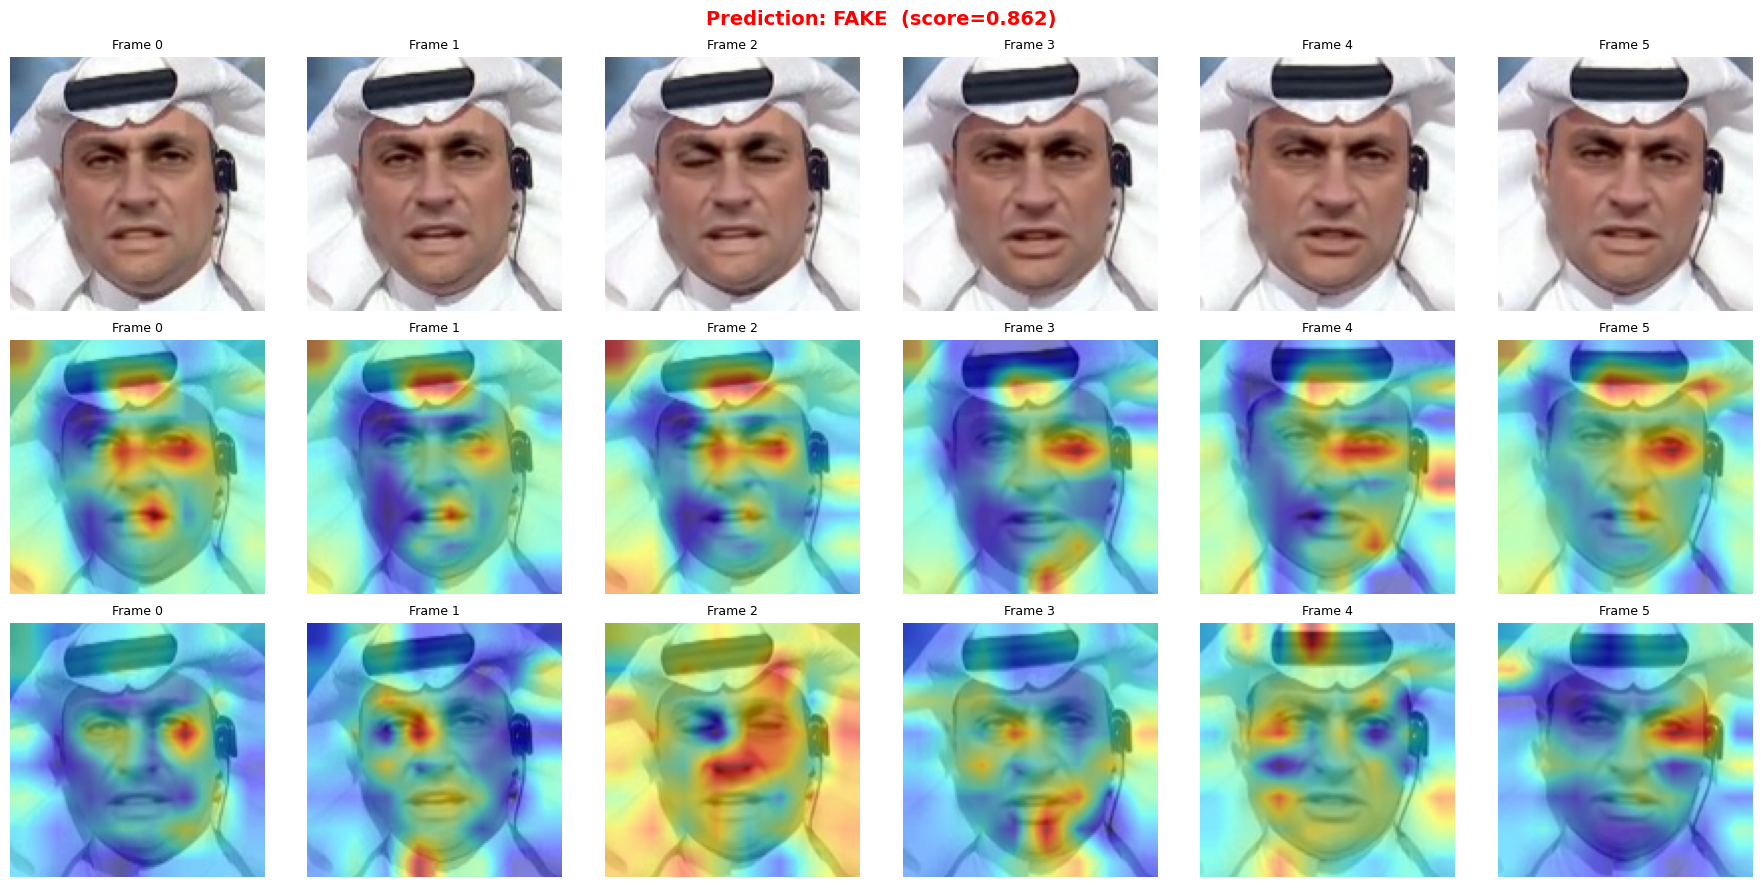

In [17]:
# ── CONFIGURE ───────────────────────────────────────────────────
CKPT_PATH  = "/content/drive/MyDrive/istvt_checkpoints/best.pt"
VIDEO_DIR  = "/content/drive/MyDrive/istvt_data/fake/000_003"   # folder of frame JPEGs to visualize
IMG_SIZE   = 128
SEQ_LEN    = 6
# ────────────────────────────────────────────────────────────────

# Load model
model = ISTVT(img_size=IMG_SIZE, seq_len=SEQ_LEN, embed_dim=256, depth=6, num_heads=8)
state = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(state["model"])
model = model.to(device)
print("Model loaded ✓")

# Load a 6-frame sequence
import os
transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(),
                       T.Normalize([0.5]*3, [0.5]*3)])
frame_files = sorted(f for f in os.listdir(VIDEO_DIR) if f.endswith(".jpg"))[:SEQ_LEN]
frames_pil  = [Image.open(os.path.join(VIDEO_DIR, f)).convert("RGB") for f in frame_files]
seq         = torch.stack([transform(f) for f in frames_pil]).unsqueeze(0)  # (1,6,3,H,W)

# Generate heatmaps
s_maps, t_maps, pred = get_heatmaps(model, seq, device)
print(f"Prediction: {'FAKE' if pred > 0.5 else 'REAL'} (score={pred:.4f})")

# Plot
frames_np = [np.array(f) for f in frames_pil]
plot_heatmaps(frames_np, s_maps, t_maps, pred, save_path="heatmaps.png")